In [1]:
def recall_at_k(relevant_ids, retrieved_ids, k):
    return int(any(doc_id in retrieved_ids[:k] for doc_id in relevant_ids))


def precision_at_k(relevant_ids, retrieved_ids, k):
    if k == 0:
        return 0.0
    hits = sum(1 for doc_id in retrieved_ids[:k] if doc_id in relevant_ids)
    return hits / k


def mrr(relevant_ids, retrieved_ids):
    for i, doc_id in enumerate(retrieved_ids, start=1):
        if doc_id in relevant_ids:
            return 1.0 / i
    return 0.0

In [2]:
import json
from pathlib import Path

# --------------------
# Helper function to get latest file by pattern
# --------------------
def get_latest_file(folder: Path, pattern: str) -> Path:
    files = list(folder.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files found matching {pattern} in {folder}")
    # Pick the file with the latest timestamp in filename
    # Assumes filenames have format like 'dense_eval_YYYYMMDDTHHMMSS.json'
    return max(files, key=lambda f: f.stem.split("_")[-1])

# --------------------
# Folders
# --------------------
eval_folder = Path("../data/eval/results")


In [3]:
from pathlib import Path
import json

eval_folder = Path("../data/eval/results")

# Latest hybrid eval
hybrid_file = get_latest_file(eval_folder, "hybrid_eval_*.json")
with open(hybrid_file) as f:
    hybrid_eval = json.load(f)

# Reranked output
reranked_file = get_latest_file(eval_folder, "hybrid_reranked_eval_*.json")
with open(reranked_file) as f:
    reranked_eval = json.load(f)

print(f"Loaded {len(hybrid_eval)} hybrid queries from {hybrid_file.name}")
print(f"Loaded {len(reranked_eval)} reranked queries from {reranked_file.name}")


Loaded 312 hybrid queries from hybrid_eval_20260308T153431.json
Loaded 312 reranked queries from hybrid_reranked_eval_20260308T161632.json


In [7]:
# Map reranked results by query
reranked_by_query = {
    item["query"]: item["reranked_doc_ids"]  # already a list of strings
    for item in reranked_eval
}


In [8]:
RERANK_K = 10

reranked_metrics = []

for item in hybrid_eval:
    query = item["query"]
    relevant_ids = item["relevant_doc_ids"]

    if query not in reranked_by_query:
        continue

    reranked_ids = reranked_by_query[query]

    reranked_metrics.append({
        "query": query,
        "method": "Hybrid + CrossEncoder",
        "recall_at_k": recall_at_k(relevant_ids, reranked_ids, RERANK_K),
        "mrr": mrr(relevant_ids, reranked_ids),
        "precision_at_k": precision_at_k(relevant_ids, reranked_ids, RERANK_K),
    })


In [9]:
import pandas as pd

df_hybrid = pd.DataFrame(hybrid_eval)
df_hybrid["method"] = "Hybrid"

df_reranked = pd.DataFrame(reranked_metrics)

metrics = ["recall_at_k", "mrr", "precision_at_k"]

df_all = pd.concat(
    [df_hybrid[["query", "method"] + metrics], df_reranked],
    ignore_index=True
)

df_all


,query,method,recall_at_k,mrr,precision_at_k
0,Why isn’t a UI element being announced or focu...,Hybrid,1,1.0,0.4
1,What debugging tools can I use to check access...,Hybrid,1,1.0,0.8
2,What do semantics mean in accessible user inte...,Hybrid,1,1.0,0.8
3,How can using a UI toolkit improve accessibili...,Hybrid,1,1.0,0.6
4,How do hosting services work with user sign-in...,Hybrid,1,1.0,0.2
...,...,...,...,...,...
619,How have easy-to-use tools made fine-tuning do...,Hybrid + CrossEncoder,1,0.5,0.1
620,"What are Gemini Extensions, and how can they f...",Hybrid + CrossEncoder,1,1.0,0.2
621,How can I use extensions to analyze my Mailchi...,Hybrid + CrossEncoder,1,1.0,0.2
622,What exactly is the smart chip feature in Goog...,Hybrid + CrossEncoder,1,1.0,0.1


In [10]:
avg_metrics = df_all.groupby("method")[metrics].mean().reset_index()
avg_metrics


,method,recall_at_k,mrr,precision_at_k
0,Hybrid,0.983974,0.921955,0.458333
1,Hybrid + CrossEncoder,0.974359,0.908868,0.196154


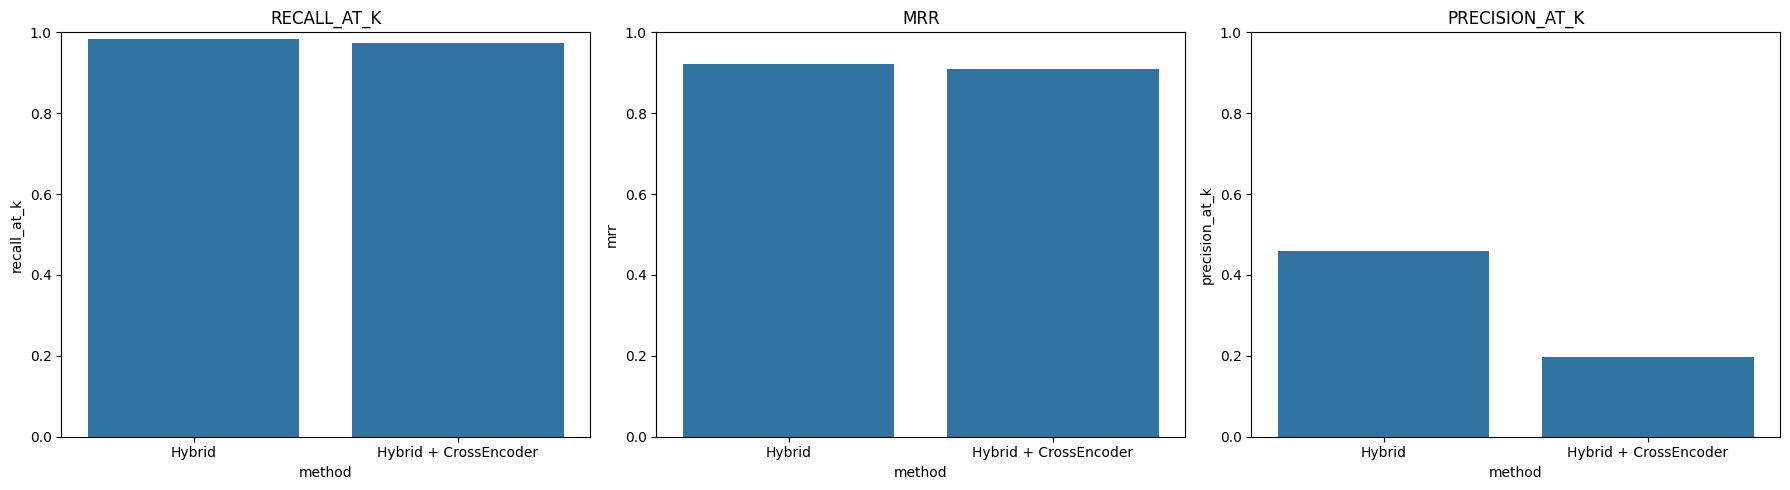

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, metric in enumerate(metrics):
    sns.barplot(data=avg_metrics, x="method", y=metric, ax=axes[i])
    axes[i].set_title(metric.upper())
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()


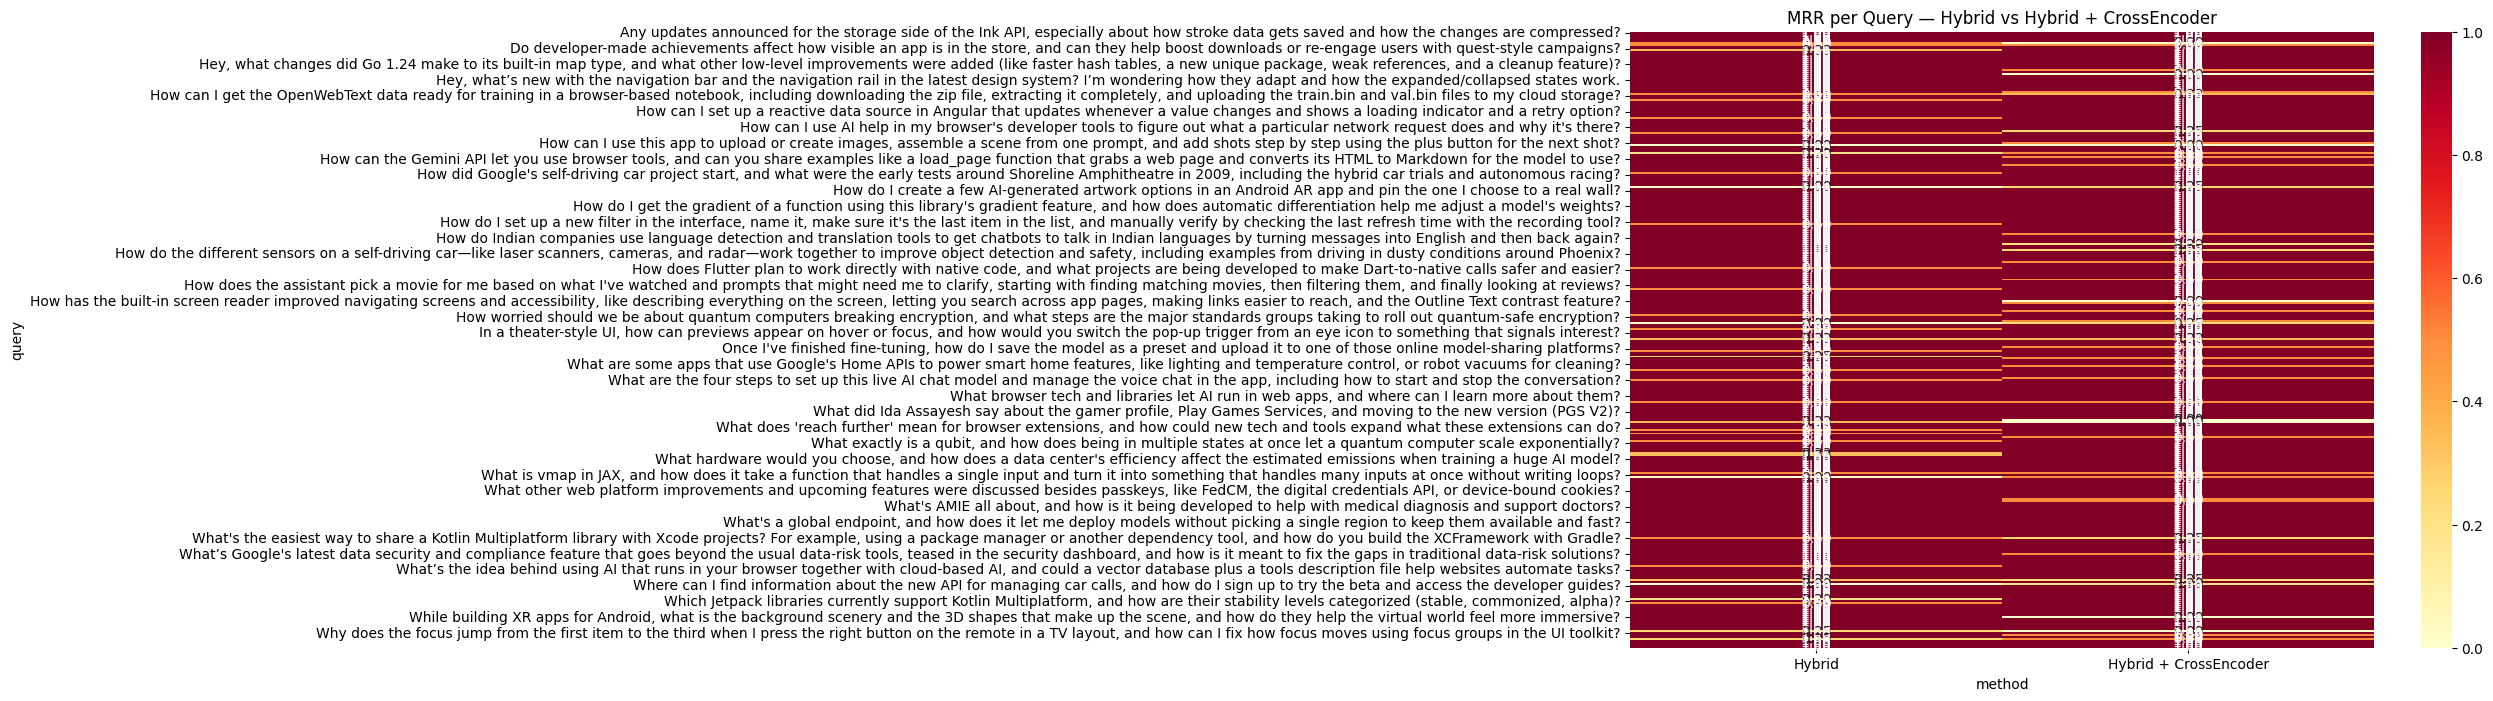

In [12]:
pivot = df_all.pivot(index="query", columns="method", values="mrr")

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("MRR per Query — Hybrid vs Hybrid + CrossEncoder")
plt.show()


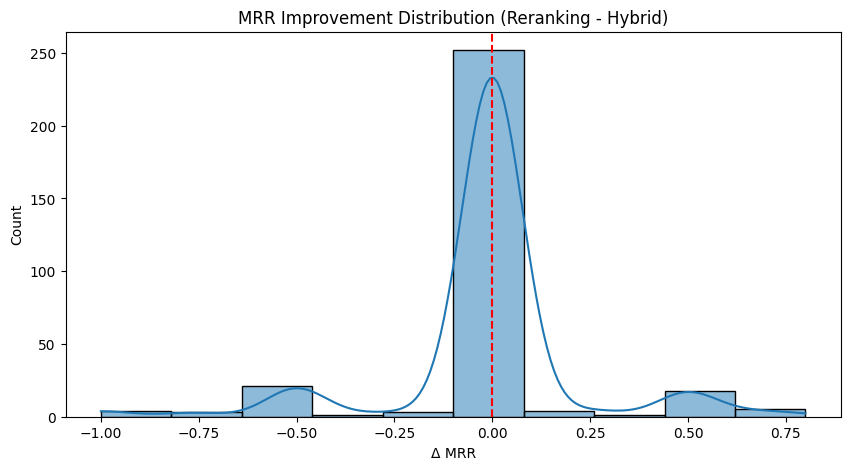

Queries improved: 28
Queries worsened: 33
Unchanged: 251


In [13]:
delta = pivot["Hybrid + CrossEncoder"] - pivot["Hybrid"]

plt.figure(figsize=(10,5))
sns.histplot(delta, bins=10, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("MRR Improvement Distribution (Reranking - Hybrid)")
plt.xlabel("Δ MRR")
plt.show()

print(f"Queries improved: {(delta > 0).sum()}")
print(f"Queries worsened: {(delta < 0).sum()}")
print(f"Unchanged: {(delta == 0).sum()}")
